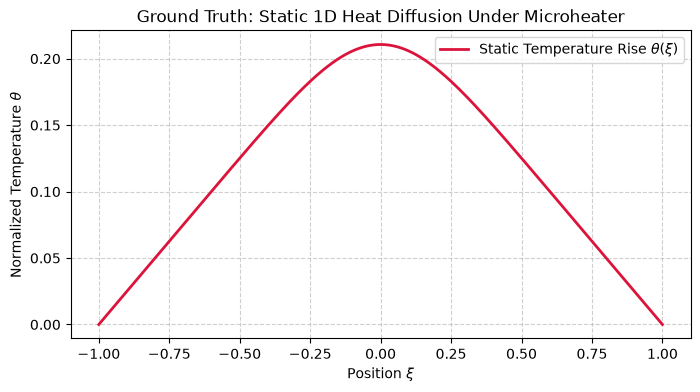

In [6]:
import sys
import os
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('..'))

from src.reference_static import solve_static_finite_difference

xi, theta = solve_static_finite_difference()

plt.figure(figsize=(8, 4))
plt.plot(xi, theta, label="Static Temperature Rise $\\theta(\\xi)$", color="crimson", linewidth=2)
plt.title("Ground Truth: Static 1D Heat Diffusion Under Microheater")
plt.xlabel("Position $\\xi$")
plt.ylabel("Normalized Temperature $\\theta$")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

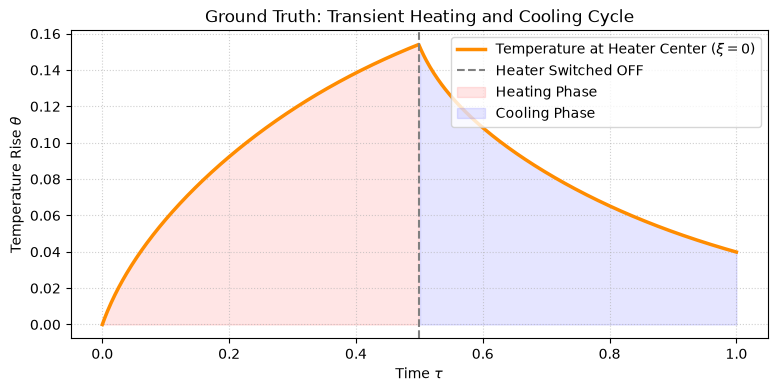

In [7]:
import numpy as np
from src.reference_transient import solve_transient_finite_difference

# Run the simulation
xi, tau, theta_history = solve_transient_finite_difference()

# Plotting the thermal evolution over time at the center of the heater (xi = 0)
center_idx = len(xi) // 2

plt.figure(figsize=(9, 4))
plt.plot(tau, theta_history[:, center_idx], color="darkorange", linewidth=2.5, label="Temperature at Heater Center ($\\xi=0$)")

# Visual markers for heating vs cooling phases
plt.axvline(x=0.5, color='gray', linestyle='--', label="Heater Switched OFF")
plt.fill_between(tau, 0, theta_history[:, center_idx], where=(tau <= 0.5), color='red', alpha=0.1, label="Heating Phase")
plt.fill_between(tau, 0, theta_history[:, center_idx], where=(tau > 0.5), color='blue', alpha=0.1, label="Cooling Phase")

plt.title("Ground Truth: Transient Heating and Cooling Cycle")
plt.xlabel("Time $\\tau$")
plt.ylabel("Temperature Rise $\\theta$")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.show()